## 2 线性代数和NDArray
### 2.1 理论计算题
已知向量 $\boldsymbol{a}=[2,-1,3]^\top$，$\boldsymbol{b}=[1,4,-2]^\top$，矩阵
$$A=\begin{bmatrix}1 &0&2\\ -1&3&1\end{bmatrix}, B=\begin{bmatrix}2 &1\\ 0 &-1\\ 3&2\end{bmatrix}$$

1. **向量点积 $\boldsymbol{a}·\boldsymbol{b}$**
$$\boldsymbol{a}·\boldsymbol{b}=2×1 + (-1)×4 + 3×(-2) = 2-4-6 = \boldsymbol{-8}$$

2. **矩阵乘法 $A×B$**
$A$ 形状 $(2×3)$，$B$ 形状 $(3×2)$，结果形状 $\boldsymbol{(2×2)}$
$$A×B=\begin{bmatrix}1×2+0×0+2×3 & 1×1+0×(-1)+2×2 \\ -1×2+3×0+1×3 & -1×1+3×(-1)+1×2\end{bmatrix}=\begin{bmatrix}8 & 5 \\ 1 & -2\end{bmatrix}$$

3. **向量$\boldsymbol{a}$的Frobenius范数**
$$||\boldsymbol{a}||_F=\sqrt{2^2+(-1)^2+3^2}=\sqrt{4+1+9}=\boldsymbol{\sqrt{14}}$$

In [1]:
# 2.2 编程题（NumPy实现）
import numpy as np

# 1. 创建3×4标准正态随机矩阵X
X = np.random.randn(3, 4)
print("X:\n", X)

# 2. 创建4×2全1矩阵Y
Y = np.ones((4, 2))
print("Y:\n", Y)

# 3. 矩阵乘法Z=X×Y
Z = np.dot(X, Y)
print("Z:\n", Z)

# 4. 输出Z第一行第二列元素 + 第二行所有元素
print("Z[0,1]:", Z[0, 1])
print("Z[1,:]:", Z[1, :])

# 5. Z的Frobenius范数
z_f_norm = np.linalg.norm(Z, 'fro')
print("Z的Frobenius范数:", z_f_norm)

X:
 [[ 0.14020487  2.29506699  1.07407404  0.43377748]
 [ 0.13386184 -0.55011388 -1.63933412  0.85812938]
 [ 1.21066692 -0.33925015 -1.06892762 -0.70694891]]
Y:
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]
Z:
 [[ 3.94312338  3.94312338]
 [-1.19745677 -1.19745677]
 [-0.90445977 -0.90445977]]
Z[0,1]: 3.943123383568853
Z[1,:]: [-1.19745677 -1.19745677]
Z的Frobenius范数: 5.9666024197060805


## 3 概率与统计
### 3.1 理论计算题（贝叶斯公式）
设：
- $A$：患病，$P(A)=0.1\%=0.001$
- $\overline{A}$：未患病，$P(\overline{A})=0.999$
- $+$：检测阳性，$P(+|A)=99\%=0.99$，$P(+|\overline{A})=2\%=0.02$

**贝叶斯公式**：
$$P(A|+) = \frac{P(+|A)P(A)}{P(+|A)P(A)+P(+|\overline{A})P(\overline{A})}$$

代入计算：
$$P(A|+) = \frac{0.99×0.001}{0.99×0.001+0.02×0.999} = \frac{0.00099}{0.02097} ≈ \boldsymbol{4.72\%}$$

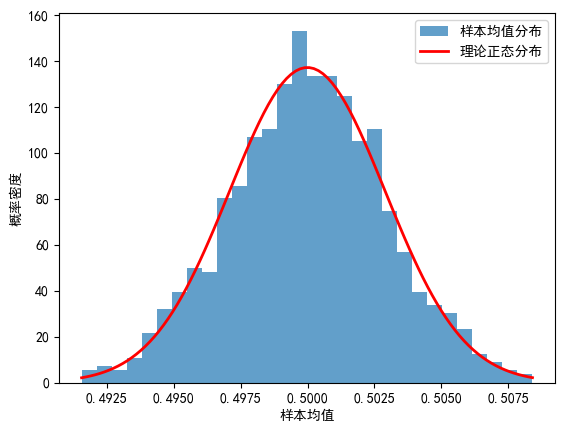

均值的实际方差: 8.469198591485668e-06


In [4]:
# 3.2 编程题：中心极限定理模拟
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'WenQuanYi Micro Hei']  # 兼容Windows/Mac/Linux中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方框的问题

# 1. 生成数据
n = 10000  # 每次样本数
m = 1000   # 重复次数
means = [np.mean(np.random.uniform(0, 1, n)) for _ in range(m)]

# 2. 绘制直方图+正态分布拟合
plt.hist(means, bins=30, density=True, alpha=0.7, label='样本均值分布')
mu, std = norm.fit(means)
x = np.linspace(min(means), max(means), 100)
plt.plot(x, norm.pdf(x, mu, std), 'r', linewidth=2, label='理论正态分布')
plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.legend()
plt.show()

# 3. 计算实际方差
var = np.var(means)
print("均值的实际方差:", var)

## 4 导数、反向传播和复杂度
### 4.1 理论计算题
函数 $z=(w_1x_1 + w_2x_2 -y)^2$，$x_1=2,x_2=1,y=3$

1. **偏导数**
$$\frac{\partial z}{\partial w_1} = 4(2w_1+w_2-3),\quad \frac{\partial z}{\partial w_2} = 2(2w_1+w_2-3)$$

2. **代入$w_1=0.5,w_2=1$**
$$2w_1+w_2-3=-1 \implies \frac{\partial z}{\partial w_1}=\boldsymbol{-4},\ \frac{\partial z}{\partial w_2}=\boldsymbol{-2}$$
梯度：$\boldsymbol{[-4, -2]}$

In [3]:
# 4.2 编程题：手动反向传播+自动微分验证
import torch

# 1. 定义前向计算
x = 2.0
w1 = 1.5
w2 = 0.5

# 手动前向
a = x * w1
b = a + w2
L = b ** 2
print("手动前向损失L:", L)

# 手动反向传播（链式法则）
dL_db = 2 * b
dL_dw1 = dL_db * x
dL_dw2 = dL_db * 1
print("手动梯度：dL/dw1={}, dL/dw2={}".format(dL_dw1, dL_dw2))

# torch自动微分验证
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)
x_t = torch.tensor(2.0)
L_t = (x_t * w1_t + w2_t) ** 2
L_t.backward()
print("自动微分梯度：dL/dw1={}, dL/dw2={}".format(w1_t.grad.item(), w2_t.grad.item()))

手动前向损失L: 12.25
手动梯度：dL/dw1=14.0, dL/dw2=7.0
自动微分梯度：dL/dw1=14.0, dL/dw2=7.0


## 5 线性方法、基础优化和SOFTMAX回归
### 5.1 理论计算题
线性回归 $y=wx+b$，均方误差 $L=\frac{1}{n}\sum_{i=1}^n(y_i-wx_i-b)^2$

**偏导数**：
$$\frac{\partial L}{\partial w} = -\frac{2}{n}\sum_{i=1}^n x_i(y_i-wx_i-b)$$
$$\frac{\partial L}{\partial b} = -\frac{2}{n}\sum_{i=1}^n (y_i-wx_i-b)$$

In [4]:
# 5.2 编程题：从零实现Softmax回归（MNIST分类）
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

# 1. 加载数据
data = load_digits()
X = data.data  # (1797,64)
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. One-hot编码
def one_hot(y, num_classes=10):
    return np.eye(num_classes)[y]

y_train_onehot = one_hot(y_train)
y_test_onehot = one_hot(y_test)

# 3. Softmax函数
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# 交叉熵损失
def cross_entropy(y_pred, y_true):
    return -np.mean(np.sum(y_true * np.log(y_pred + 1e-8), axis=1))

# 4. 初始化参数
input_dim = 64
num_classes = 10
W = np.random.randn(input_dim, num_classes) * 0.01
b = np.zeros((1, num_classes))
lr = 0.1
epochs = 50
batch_size = 32

# 训练
for epoch in range(epochs):
    idx = np.random.permutation(len(X_train))
    X_shuffle = X_train[idx]
    y_shuffle = y_train_onehot[idx]
    loss = 0

    for i in range(0, len(X_train), batch_size):
        X_batch = X_shuffle[i:i+batch_size]
        y_batch = y_shuffle[i:i+batch_size]

        # 前向
        z = np.dot(X_batch, W) + b
        y_pred = softmax(z)
        loss += cross_entropy(y_pred, y_batch)

        # 反向
        dz = y_pred - y_batch
        dW = np.dot(X_batch.T, dz) / len(X_batch)
        db = np.sum(dz, axis=0) / len(X_batch)

        # 更新
        W -= lr * dW
        b -= lr * db

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss/(len(X_train)/batch_size):.4f}")

# 5. 测试准确率
z_test = np.dot(X_test, W) + b
y_pred_test = softmax(z_test)
acc = np.mean(np.argmax(y_pred_test, axis=1) == y_test)
print(f"测试集准确率: {acc:.4f}")

Epoch 10, Loss: 0.2747
Epoch 20, Loss: 0.1012
Epoch 30, Loss: 0.0302
Epoch 40, Loss: 0.2079
Epoch 50, Loss: 0.0003
测试集准确率: 0.9667


## 6 最大似然估计和逻辑回归
### 6.1 理论计算题
样本 $x_1,...,x_n \sim N(\mu,\sigma^2)$ 独立同分布

1. **似然函数**
$$L(\mu,\sigma^2)=\prod_{i=1}^n \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{(x_i-\mu)^2}{2\sigma^2}\right)$$

2. **$\mu$的MLE**
对数似然求导得：$\sum_{i=1}^n(x_i-\mu)=0 \implies \hat{\mu}=\frac{1}{n}\sum_{i=1}^n x_i$

3. **$\sigma^2$的MLE**
对数似然对$\sigma^2$求导得：$\hat{\sigma}^2=\frac{1}{n}\sum_{i=1}^n(x_i-\hat{\mu})^2$

Iter 0, Loss: 0.6890
Iter 100, Loss: 0.0323
Iter 200, Loss: 0.0222
Iter 300, Loss: 0.0183
Iter 400, Loss: 0.0161
Iter 500, Loss: 0.0146
Iter 600, Loss: 0.0135
Iter 700, Loss: 0.0126
Iter 800, Loss: 0.0119
Iter 900, Loss: 0.0114
测试集准确率: 1.0000


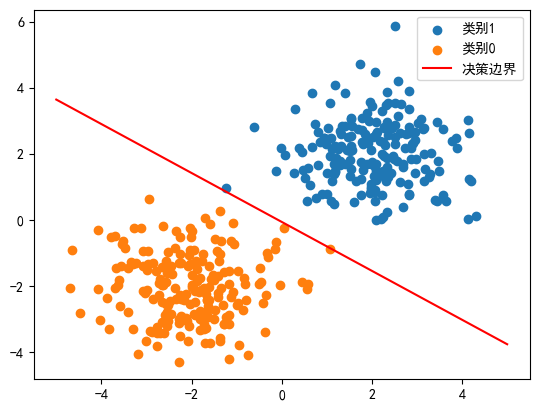

In [5]:
# 6.2 编程题：从零实现二分类逻辑回归
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'WenQuanYi Micro Hei']  # 兼容Windows/Mac/Linux中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方框的问题

# 1. 生成线性可分数据
np.random.seed(42)
n = 200
X1 = np.random.randn(n, 2) + np.array([2, 2])
X2 = np.random.randn(n, 2) + np.array([-2, -2])
X = np.vstack((X1, X2))
y = np.hstack((np.ones(n), np.zeros(n)))

# 训练/测试集
X_train, X_test = X[:300], X[300:]
y_train, y_test = y[:300], y[300:]

# 2. Sigmoid+交叉熵
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    return -np.mean(y_true*np.log(y_pred+1e-8) + (1-y_true)*np.log(1-y_pred+1e-8))

# 3. 梯度下降训练
w = np.random.randn(2) * 0.01
b = 0.0
lr = 0.1
iterations = 1000

for i in range(iterations):
    z = np.dot(X_train, w) + b
    y_pred = sigmoid(z)
    loss = binary_cross_entropy(y_pred, y_train)

    # 梯度
    dz = y_pred - y_train
    dw = np.dot(X_train.T, dz) / len(X_train)
    db = np.mean(dz)

    # 更新
    w -= lr * dw
    b -= lr * db

    if i % 100 == 0:
        print(f"Iter {i}, Loss: {loss:.4f}")

# 4. 测试准确率+决策边界
y_pred_test = sigmoid(np.dot(X_test, w) + b) > 0.5
acc = np.mean(y_pred_test == y_test)
print(f"测试集准确率: {acc:.4f}")

# 绘图
plt.scatter(X1[:,0], X1[:,1], label='类别1')
plt.scatter(X2[:,0], X2[:,1], label='类别0')
x_line = np.array([-5, 5])
y_line = -(w[0]*x_line + b) / w[1]
plt.plot(x_line, y_line, 'r-', label='决策边界')
plt.legend()
plt.show()